In [1]:
#Run in terminal
#pip install medmnist
#pip -m install dlordinal

In [2]:
#Packages
from medmnist import RetinaMNIST
import pandas as pd
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from torch.utils.data import DataLoader
import torch.nn as nn
import dlordinal
from dlordinal.metrics import amae, mmae, accuracy_off1
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier


Dataset RetinaMNIST of size 28 (retinamnist)
    Number of datapoints: 1080
    Root location: C:\Users\Aleksandra\.medmnist
    Split: train
    Task: ordinal-regression
    Number of channels: 3
    Meaning of labels: {'0': '0', '1': '1', '2': '2', '3': '3', '4': '4'}
    Number of samples: {'train': 1080, 'val': 120, 'test': 400}
    Description: The RetinaMNIST is based on the DeepDRiD challenge, which provides a dataset of 1,600 retina fundus images. The task is ordinal regression for 5-level grading of diabetic retinopathy severity. We split the source training set with a ratio of 9:1 into training and validation set, and use the source validation set as the test set. The source images of 3×1,736×1,824 are center-cropped and resized into 3×28×28.
    License: CC BY 4.0


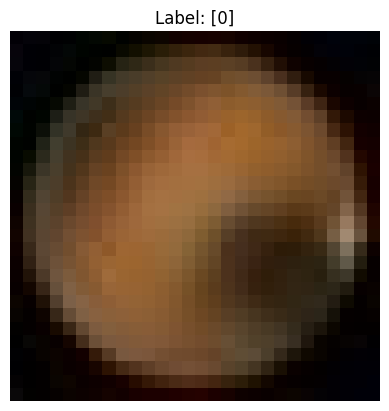


TRAIN split:
  Label 0: 486 images
  Label 1: 128 images
  Label 2: 206 images
  Label 3: 194 images
  Label 4: 66 images

VAL split:
  Label 0: 54 images
  Label 1: 12 images
  Label 2: 28 images
  Label 3: 20 images
  Label 4: 6 images

TEST split:
  Label 0: 174 images
  Label 1: 46 images
  Label 2: 92 images
  Label 3: 68 images
  Label 4: 20 images
total over train, val and test
Label 0: 714 images
Label 1: 186 images
Label 2: 326 images
Label 3: 282 images
Label 4: 92 images


In [3]:
#Loading and preparing the data
train_data = RetinaMNIST(split="train", download=True)
val_data = RetinaMNIST(split="val", download=True)
test_data = RetinaMNIST(split="test", download=True)

train_data_raw = RetinaMNIST(split="train", download=True)
val_data_raw = RetinaMNIST(split="val", download=True)
test_data_raw = RetinaMNIST(split="test", download=True)

print(train_data) #There are 5 labels that classify increasing severity of diabetic retinopathy

#Example of an image
img, label = train_data[0]
plt.imshow(img, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

#Distribution of classifications in data. In each dataset, the distribution of classifications is similar.
splits = ["train", "val", "test"]
all_counts = {}
total_counts = Counter()
for split in splits:
    ds = RetinaMNIST(split=split, download=True)
    labels = [int(ds[i][1].item()) for i in range(len(ds))]
    all_counts[split] = Counter(labels)
    total_counts.update(labels)
for split in splits:
    print(f"\n{split.upper()} split:")
    for label, count in sorted(all_counts[split].items()):
        print(f"  Label {label}: {count} images")
print("total over train, val and test")
for label in sorted(total_counts.keys()):
    print(f"Label {label}: {total_counts[label]} images")


In [4]:
# Select all images from the training set 
all_images = np.stack([np.array(train_data[i][0]) for i in range(len(train_data))])

channel_names = ['R', 'G', 'B']
channel_means = []
channel_stds  = []

# Calculate mean and std for each channel
for c, name in enumerate(channel_names):
    ch = all_images[:, :, :, c]
    channel_means.append(ch.mean())
    channel_stds.append(ch.std())
    # print(f"Channel {name} — mean: {ch.mean():.3f}, std: {ch.std():.3f}")


mean = [channel_means[0]/255, channel_means[1]/255, channel_means[2]/255]
std  = [channel_stds[0]/255, channel_stds[1]/255, channel_stds[2]/255]

print(f"Channel means: {mean}")
print(f"Channel stds: {std}")

# converts image to tensor and scales to [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),      
    transforms.Normalize(mean=mean, std=std)
])

# Apply the transformations to the datasets
train_data = RetinaMNIST(split='train', download=True, transform=transform)
val_data   = RetinaMNIST(split='val',   download=True, transform=transform)
test_data  = RetinaMNIST(split='test',  download=True, transform=transform)

Channel means: [0.39838941595156585, 0.24472671012849584, 0.15575321332236597]
Channel stds: [0.29828646114778967, 0.20048242021552953, 0.15065953323691264]


LR val accuracy: 0.4583
One-off accuracy: 0.7750
Average mean absolute error (AMAE): 1.0584
Maximum mean absolute error (MMAE): 1.6667
Quadratic weighted kappa: 0.4939

RF val accuracy: 0.4917
One-off accuracy: 0.7833
Average mean absolute error (AMAE): 1.0033
Maximum mean absolute error (MMAE): 1.4000
Quadratic weighted kappa: 0.5006



C:\Users\Aleksandra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Aleksandra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


SVC val accuracy: 0.4667
One-off accuracy: 0.7667
Average mean absolute error (AMAE): 1.0480
Maximum mean absolute error (MMAE): 1.8333
Quadratic weighted kappa: 0.5473

KNN val accuracy: 0.5000
One-off accuracy: 0.7583
Average mean absolute error (AMAE): 1.0854
Maximum mean absolute error (MMAE): 2.0000
Quadratic weighted kappa: 0.4616



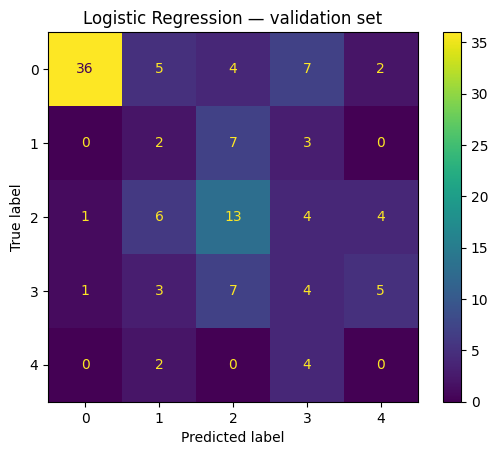

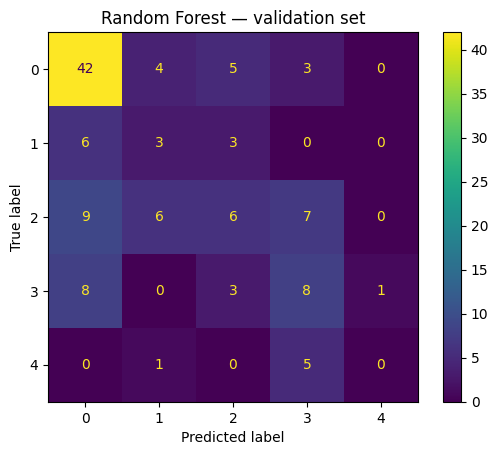

TEST results Logistic regression
LR test accuracy: 0.4875
One-off accuracy: 0.7400
Average mean absolute error (AMAE): 1.0868
Maximum mean absolute error (MMAE): 1.7500
Quadratic weighted kappa: 0.5135

TEST results Random forest
RF test accuracy: 0.5125
One-off accuracy: 0.7350
Average mean absolute error (AMAE): 1.3621
Maximum mean absolute error (MMAE): 3.2000
Quadratic weighted kappa: 0.3700

SVC test accuracy: 0.4950
One-off accuracy: 0.7325
Average mean absolute error (AMAE): 1.1906
Maximum mean absolute error (MMAE): 2.2500
Quadratic weighted kappa: 0.4862

KNN test accuracy: 0.4925
One-off accuracy: 0.7525
Average mean absolute error (AMAE): 1.3068
Maximum mean absolute error (MMAE): 2.8000
Quadratic weighted kappa: 0.4210



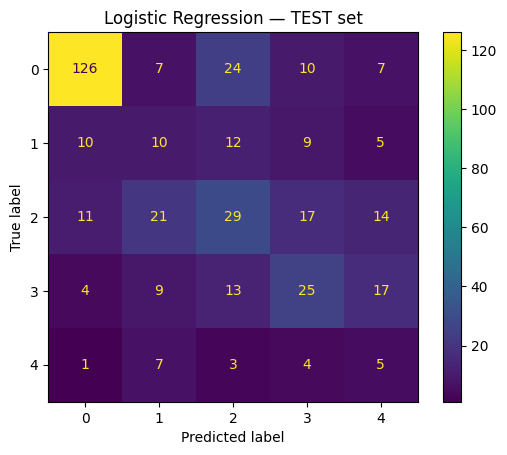

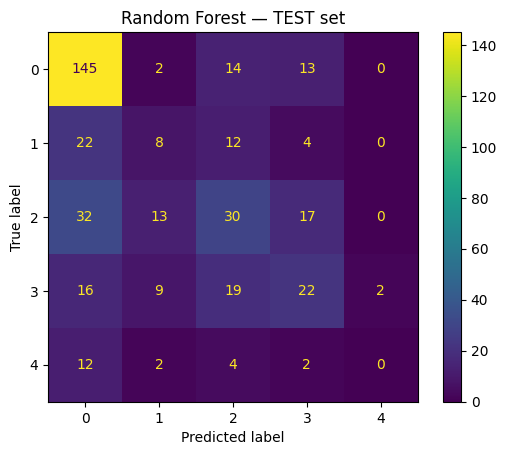

In [5]:
# Baseline model training

# Flatten the images, because sklearn models expects 1D feature vectors, not 2D images
def prepare_sklearn_data(dataset) :
    images = np.stack([np.array(dataset[i][0]) for i in range(len(dataset))])
    labels = np.array([dataset[i][1].item() for i in range(len(dataset))])
    # flatten each image from (28, 28, 3) to (2352)
    images = images.reshape(len(dataset), -1)
    # normalize to [0, 1]
    images = images / 255.0
    return images, labels

# Create new flat datasets with normalized pixel values
X_train, y_train = prepare_sklearn_data(train_data_raw)
X_val,   y_val   = prepare_sklearn_data(val_data_raw)
X_test,  y_test  = prepare_sklearn_data(test_data_raw)

# Train a logistic regression model 
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced') # class_weight='balanced' to handle class imbalance in the dataset
model.fit(X_train, y_train)

lr_val_preds = model.predict(X_val)
lr_val_acc = accuracy_score(y_val, lr_val_preds)
print(f"LR val accuracy: {lr_val_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_val, lr_val_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_val, lr_val_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_val, lr_val_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_val, lr_val_preds, weights='quadratic'):.4f}\n")


# Train a random forest model 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # class_weight='balanced' to handle class imbalance in the dataset
rf_model.fit(X_train, y_train)

rf_val_preds = rf_model.predict(X_val)
rf_val_acc = accuracy_score(y_val, rf_val_preds)
print(f"RF val accuracy: {rf_val_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_val, rf_val_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_val, rf_val_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_val, rf_val_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_val, rf_val_preds, weights='quadratic'):.4f}\n")

# Train a linear SVM model 
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]
best_C, best_svc_acc = None, -1.0  # initialize variables to assure first loop will score the lowest c value. next loop will always update because it will score higher than -1

# Find best performing Regularization parameter C for linear SVM model
for C in C_values:
    # Training model with various c values and saving the best
    svc = LinearSVC(C=C, max_iter=7000, random_state=42, class_weight='balanced') # class_weight='balanced' to handle class imbalance in the dataset
    svc.fit(X_train, y_train)
    acc = accuracy_score(y_val, svc.predict(X_val))
    if acc > best_svc_acc:
        best_svc_acc, best_C = acc, C

# print(f"Best C: {best_C}")

# Retrain with best C
svc_model = LinearSVC(C=best_C, max_iter=7000, random_state=42, class_weight='balanced') # class_weight='balanced' to handle class imbalance in the dataset
svc_model.fit(X_train, y_train)

svc_val_preds = svc_model.predict(X_val) 
svc_val_acc = accuracy_score(y_val, svc_val_preds)
print(f"SVC val accuracy: {svc_val_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_val, svc_val_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_val, svc_val_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_val, svc_val_preds):.4f}") 
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_val, svc_val_preds, weights='quadratic'):.4f}\n")

# Train a k-nearest neighbors model
k_values = [1, 3, 5, 7, 9, 11, 15]
best_k, best_knn_acc = None, -1.0 # initialize variables to assure first loop will score the lowest k value. next loop will always update because it will score higher than -1

# Find best performing k for k-nearest neighbors model
for k in k_values:
    # Training model with various k values and saving the best
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance') # weights='balanced' to handle class imbalance in the dataset
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_val, knn.predict(X_val))
    if acc > best_knn_acc:
        best_knn_acc, best_k = acc, k

# print(f"Best k: {best_k}")

#  Retrain with best k
knn_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn_model.fit(X_train, y_train)

knn_val_preds = knn_model.predict(X_val)
knn_val_acc = accuracy_score(y_val, knn_val_preds)
print(f"KNN val accuracy: {knn_val_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_val, knn_val_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_val, knn_val_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_val, knn_val_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_val, knn_val_preds, weights='quadratic'):.4f}\n")

# Plot confusion matrix that displays the correct classification of samples predicted for each class (X) vs the true class labels (y)
cm = confusion_matrix(y_val, lr_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Logistic Regression — validation set")
plt.show()

cm = confusion_matrix(y_val, rf_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Random Forest — validation set")
plt.show()


####TESTING
lr_test_preds = model.predict(X_test)
lr_test_acc = accuracy_score(y_test, lr_test_preds)
print("TEST results Logistic regression")
print(f"LR test accuracy: {lr_test_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_test, lr_test_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_test, lr_test_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_test, lr_test_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_test, lr_test_preds, weights='quadratic'):.4f}\n")


rf_test_preds = rf_model.predict(X_test)
rf_test_acc = accuracy_score(y_test, rf_test_preds)
print("TEST results Random forest")
print(f"RF test accuracy: {rf_test_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_test, rf_test_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_test, rf_test_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_test, rf_test_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_test, rf_test_preds, weights='quadratic'):.4f}\n")


svc_test_preds = svc_model.predict(X_test) 
svc_test_acc = accuracy_score(y_test, svc_test_preds)
print(f"SVC test accuracy: {svc_test_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_test, svc_test_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_test, svc_test_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_test, svc_test_preds):.4f}") 
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_test, svc_test_preds, weights='quadratic'):.4f}\n")

knn_test_preds = knn_model.predict(X_test)
knn_test_acc = accuracy_score(y_test, knn_test_preds)
print(f"KNN test accuracy: {knn_test_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_test, knn_test_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_test, knn_test_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_test, knn_test_preds):.4f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(y_test, knn_test_preds, weights='quadratic'):.4f}\n")

cm = confusion_matrix(y_test, lr_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Logistic Regression — TEST set")
plt.show()

cm = confusion_matrix(y_test, rf_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Random Forest — TEST set")
plt.show()

In [6]:
# return dataloaders for the RetinaMNIST dataset, given the mean and std for normalization and the batch size.
def get_dataloaders(mean, std, batch_size=32): #  feed 32 images at a time
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    train_data = RetinaMNIST(split='train', download=True, transform=transform)
    val_data   = RetinaMNIST(split='val',   download=True, transform=transform)
    test_data  = RetinaMNIST(split='test',  download=True, transform=transform)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True) # shuffle the training data to help the model generalize better
    val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False) # no need to shuffle validation and test data, because we only evaluate the model on them, not train on them
    test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

# Wrap in Pytorch dataloader objects to enable batching and shuffling
train_loader, val_loader, test_loader = get_dataloaders(mean=mean, std=std)



In [7]:
# Define CNN model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3,6,5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6,16,5)
        self.fc1 = nn.Linear(16*4*4,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,5)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16*4*4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

# Define loss function and optimizer (CHOICES)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001) # define optimizer with best learning rate found in test_optimizer.py 

# Model training
epochs = 20 # the amount of passes through the train_loader
min_validation_loss = np.inf # initialises a loss variable for validation loss

for e in range(epochs):
    #Instantiate running loss
    train_loss_epoch = 0.0
    net.train() #Puts model in training mode
    for i, data in enumerate(train_loader, 0):
        train_inputs, train_labels = data
        #Squeezes the image to 1D
        train_labels = train_labels.squeeze().long()
        #Clears the gradients
        optimizer.zero_grad()
        #Runs the forward pass
        train_outputs = net(train_inputs)
        #Finds the loss
        train_loss = criterion(train_outputs, train_labels)
        #Calculates gradients
        train_loss.backward()
        #Updates weights
        optimizer.step()
        #Sums all loss over the epoch and calculates an average loss per batch
        train_loss_epoch += train_loss.item()

    train_loss_epoch /= len(train_loader)
    
    #Model evaluation
    net.eval() # Puts model in evaluation mode
    validation_loss = 0.0 # Instantiates a validation loss
    #Turns off the gradient for evaluation
    with torch.no_grad():
        #For each batch, predict a label and calculate the loss
        for val_inputs, val_labels in val_loader:
            val_labels = val_labels.squeeze().long()
            val_outputs = net(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            #Sums all loss over the epoch and calculates an average loss per batch
            validation_loss += val_loss.item()
    validation_loss /= len(val_loader)

    #Prints the average training and validation loss of the epoch
    print(f'Epoch {e+1} Training Loss: {train_loss_epoch:.4f} Validation Loss: {validation_loss:.4f}')
    #Saves a model if its validation loss is lower than the currently lowest validation loss
    if min_validation_loss > validation_loss:
        print(f"Validation loss decreased from {min_validation_loss:.4f} to {validation_loss:.4f}. Saving the model")
        min_validation_loss = validation_loss
        torch.save(net.state_dict(), 'saved_model.pth')

Epoch 1 Training Loss: 1.3728 Validation Loss: 1.2284
Validation loss decreased from inf to 1.2284. Saving the model
Epoch 2 Training Loss: 1.2388 Validation Loss: 1.1197
Validation loss decreased from 1.2284 to 1.1197. Saving the model
Epoch 3 Training Loss: 1.2017 Validation Loss: 1.1667
Epoch 4 Training Loss: 1.1906 Validation Loss: 1.1084
Validation loss decreased from 1.1197 to 1.1084. Saving the model
Epoch 5 Training Loss: 1.1640 Validation Loss: 1.1265
Epoch 6 Training Loss: 1.1567 Validation Loss: 1.0828
Validation loss decreased from 1.1084 to 1.0828. Saving the model
Epoch 7 Training Loss: 1.1472 Validation Loss: 1.1074
Epoch 8 Training Loss: 1.1255 Validation Loss: 1.0678
Validation loss decreased from 1.0828 to 1.0678. Saving the model
Epoch 9 Training Loss: 1.1234 Validation Loss: 1.1293
Epoch 10 Training Loss: 1.1195 Validation Loss: 1.0607
Validation loss decreased from 1.0678 to 1.0607. Saving the model
Epoch 11 Training Loss: 1.0918 Validation Loss: 1.0607
Epoch 12 Tr